### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="notebook")
import os
#os.getcwd()
#print("Current working directory:", os.getcwd())
#print("Files in current directory:", os.listdir())
#print("Files in data directory:", os.listdir('Data'))


### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [3]:
data = pd.read_csv('Data/coupons.csv')
data.shape[0]

12684

In [4]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,car,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [5]:
data.info()
nulls = data.isna().sum().sort_values(ascending=False)
display(nulls)

pct_missing = (data.isna().mean().sort_values(ascending=False) * 100).round(2)
display(pct_missing)

# Peek at unique values in a few key categorical columns (first 12 values shown)
cols_to_check = ["coupon", "passanger", "weather", "time", "expiration", "Bar", "CoffeeHouse"]

for col in cols_to_check:
    if col in data.columns:
        print(f"\n{col} -> uniques (first 12 shown):")
        uniques = pd.Series(data[col].unique()).dropna().astype(str).head(12).to_list()
        print(uniques)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

car                     12576
CoffeeHouse               217
Restaurant20To50          189
CarryAway                 151
RestaurantLessThan20      130
Bar                       107
destination                 0
passanger                   0
direction_opp               0
direction_same              0
toCoupon_GEQ25min           0
toCoupon_GEQ15min           0
toCoupon_GEQ5min            0
income                      0
occupation                  0
education                   0
has_children                0
maritalStatus               0
age                         0
gender                      0
expiration                  0
coupon                      0
time                        0
temperature                 0
weather                     0
Y                           0
dtype: int64

car                     99.15
CoffeeHouse              1.71
Restaurant20To50         1.49
CarryAway                1.19
RestaurantLessThan20     1.02
Bar                      0.84
destination              0.00
passanger                0.00
direction_opp            0.00
direction_same           0.00
toCoupon_GEQ25min        0.00
toCoupon_GEQ15min        0.00
toCoupon_GEQ5min         0.00
income                   0.00
occupation               0.00
education                0.00
has_children             0.00
maritalStatus            0.00
age                      0.00
gender                   0.00
expiration               0.00
coupon                   0.00
time                     0.00
temperature              0.00
weather                  0.00
Y                        0.00
dtype: float64


coupon -> uniques (first 12 shown):
['Restaurant(<20)', 'Coffee House', 'Carry out & Take away', 'Bar', 'Restaurant(20-50)']

passanger -> uniques (first 12 shown):
['Alone', 'Friend(s)', 'Kid(s)', 'Partner']

weather -> uniques (first 12 shown):
['Sunny', 'Rainy', 'Snowy']

time -> uniques (first 12 shown):
['2PM', '10AM', '6PM', '7AM', '10PM']

expiration -> uniques (first 12 shown):
['1d', '2h']

Bar -> uniques (first 12 shown):
['never', 'less1', '1~3', 'gt8', '4~8']

CoffeeHouse -> uniques (first 12 shown):
['never', 'less1', '4~8', '1~3', 'gt8']


In [6]:
data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [7]:
# Clean a selected set of text columns if they exist in df
df = data.copy()

cols = ["coupon", "passanger", "weather", "time",
        "expiration", "gender", "age", "maritalStatus", "education",
        "occupation", "income", "Bar", "CoffeeHouse",
        "CarryAway", "RestaurantLessThan20", "Restaurant20To50"]

# Only keep those columns that are present and are text-like
text_like = (
    pd.Index(cols)
      .intersection(df.columns)
      .intersection(df.select_dtypes(include=["object", "string"]).columns)
)

# Strip whitespace
df[text_like] = df[text_like].apply(lambda s: s.str.strip())

# Normalize common “empty” tokens to NaN
df[text_like] = df[text_like].replace({"": np.nan, "nan": np.nan, "None": np.nan})

df.head(3)

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,car,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,1


4. What proportion of the total observations chose to accept the coupon?



In [8]:
data[data['Y'] == 1].shape[0]
print("The total number of drivers who accepted cupons are ",(data[data['Y'] == 1].shape[0]))

The total number of drivers who accepted cupons are  7210


In [9]:
accept_rate = df["Y"].mean()
print("Overall acceptance rate: {accept_rate:.3f} ({accept_rate*100:.1f}%)")
if "coupon" in df.columns:    
    by_coupon = df.groupby("coupon")["Y"].mean().sort_values(ascending=False)    
    display(by_coupon)

Overall acceptance rate: {accept_rate:.3f} ({accept_rate*100:.1f}%)


coupon
Carry out & Take away    0.735478
Restaurant(<20)          0.707107
Coffee House             0.499249
Restaurant(20-50)        0.441019
Bar                      0.410015
Name: Y, dtype: float64

5. Use a bar plot to visualize the `coupon` column.

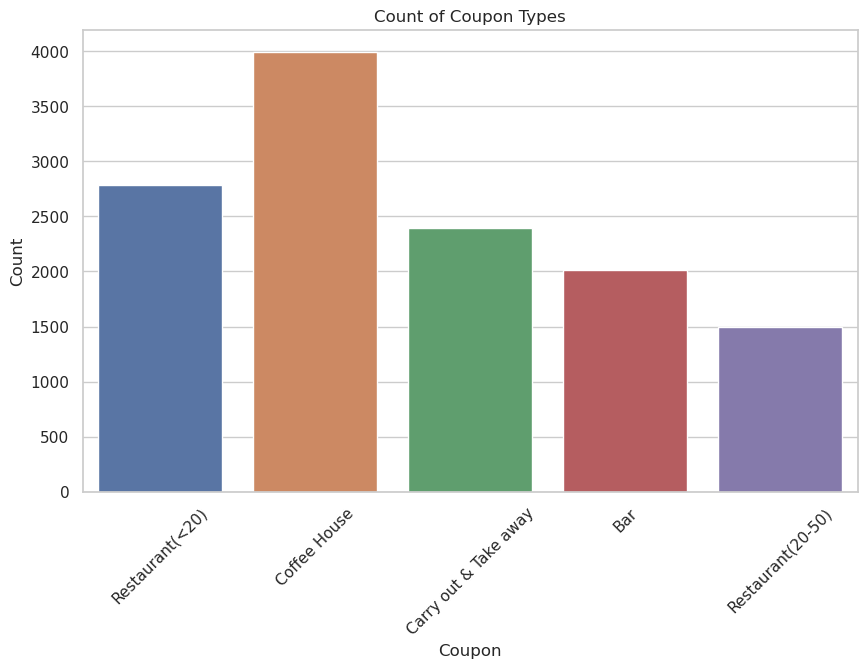

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='coupon')
plt.title('Count of Coupon Types')
plt.xlabel('Coupon')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.savefig("Images/CouponBar.png", dpi=300, bbox_inches='tight')
plt.show()

6. Use a histogram to visualize the temperature column.

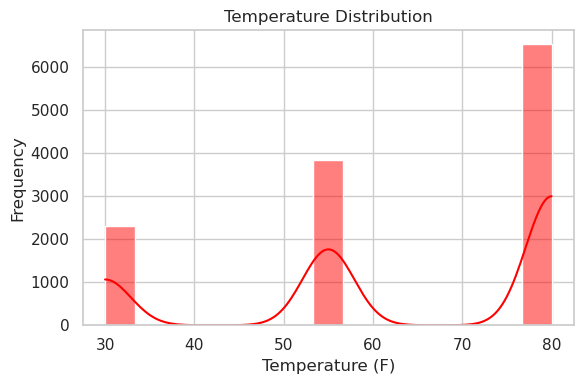

<Figure size 640x480 with 0 Axes>

In [11]:
# Cell 6
plt.figure(figsize=(6,4))
sns.histplot(df["temperature"], bins=15, kde=True, color="red")
plt.title("Temperature Distribution")
plt.xlabel("Temperature (F)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
plt.savefig("Images/TempHist2.png", dpi=300, bbox_inches='tight')

In [12]:
#Helpers for bar-related analysis

In [13]:

def freq_more_than_once(x: pd.Series) -> pd.Series:
    """More than once a month: 1~3, 4~8, gt8."""
    return x.isin(["1~3", "4~8", "gt8"])

def freq_three_or_fewer(x: pd.Series) -> pd.Series:
    """Three or fewer: never, less1, 1~3."""
    return x.isin(["never", "less1", "1~3"])

def freq_more_than_three(x: pd.Series) -> pd.Series:
    """>3 per month: 4~8, gt8."""
    return x.isin(["4~8", "gt8"])

# Age parser: '50plus' -> 50; numeric strings -> float; anything else -> NaN
def parse_age(age_str: str) -> float:
    if pd.isna(age_str):
        return np.nan
    s = str(age_str).strip().lower()
    if "plus" in s:
        # e.g., "50plus" -> 50.0
        return float(s.replace("plus", "").strip())
    try:
        return float(s)
    except ValueError:
        return np.nan

# Create numeric age and convenience flags on df
df["age_num"] = df["age"].apply(parse_age)

df["_bar_gt1"] = freq_more_than_once(df["Bar"])      # bar > 1x/mo
df["_bar_le3"] = freq_three_or_fewer(df["Bar"])      # bar <= 3x/mo
df["_bar_gt3"] = freq_more_than_three(df["Bar"])     # bar > 3x/mo
df["_not_kid"] = df["passanger"].ne("Kid(s)")        # note: column is 'passanger' in this dataset

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [14]:
# Cell 8
bar_df = df.loc[df["coupon"] == "Bar"].copy()
print("Bar-coupon rows: {bar_df.shape[0]}")
bar_df.head()
bar_df.shape[0]
print("The total number of drivers who got Bar cupons are",(bar_df.shape[0]))

Bar-coupon rows: {bar_df.shape[0]}
The total number of drivers who got Bar cupons are 2017


2. What proportion of bar coupons were accepted?


In [15]:
# Cell 9
bar_accept_rate = bar_df["Y"].mean()
print("Bar coupon acceptance rate: {:.3f} ({:.1f}%)".format(bar_accept_rate, bar_accept_rate*100))

Bar coupon acceptance rate: 0.410 (41.0%)


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [18]:
# Cell 10
subset = bar_df.dropna(subset=["Bar"])  # ensure valid categories
rate_le3 = subset.loc[df["_bar_le3"], "Y"].mean()
rate_gt3 = subset.loc[df["_bar_gt3"], "Y"].mean()
print(f"Bar visits ≤3/mo -> acceptance: {rate_le3:.3f} ({rate_le3*100:.1f}%)")
print(f"Bar visits >3/mo -> acceptance: {rate_gt3:.3f} ({rate_gt3*100:.1f}%)")

Bar visits ≤3/mo -> acceptance: 0.371 (37.1%)
Bar visits >3/mo -> acceptance: 0.769 (76.9%)


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [20]:
# Cell 11
cond_target = bar_df["_bar_gt1"] & (bar_df["age_num"] > 25)
rate_target = bar_df.loc[cond_target, "Y"].mean()
rate_others = bar_df.loc[~cond_target, "Y"].mean()
print(f"Acceptance rate of people who go to bar more than once a month & age > 25 -> acceptance: {rate_target:.3f} ({rate_target*100:.1f}%)")
print(f"Acceptance rate All others -> acceptance: {rate_others:.3f} ({rate_others*100:.1f}%)")

Acceptance rate of people who go to bar more than once a month & age > 25 -> acceptance: 0.695 (69.5%)
Acceptance rate All others -> acceptance: 0.335 (33.5%)


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [22]:
# Cell 12
occ = bar_df["occupation"].astype(str).str.lower().str.replace(r"\s+", " ", regex=True)
not_fff = ~occ.str.contains("farming.*fishing.*forestry|farming fishing & forestry")
cond = bar_df["_bar_gt1"] & bar_df["_not_kid"] & not_fff
rate_cond = bar_df.loc[cond, "Y"].mean()
rate_else = bar_df.loc[~cond, "Y"].mean()
print(f"Acceptance rate of drivers who go to bar more than once a month & passangers not kid & occuptation not farming, fishing or forestry -> {rate_cond:.3f} ({rate_cond*100:.1f}%)")
print(f"Acceptance rate of Everyone else -> {rate_else:.3f} ({rate_else*100:.1f}%)")

Acceptance rate of drivers who go to bar more than once a month & passangers not kid & occuptation not farming, fishing or forestry -> 0.713 (71.3%)
Acceptance rate of Everyone else -> 0.296 (29.6%)


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [29]:
# Cell 13

not_widowed = bar_df["maritalStatus"].astype(str).str.lower().ne("widowed")

cond_A = (bar_df["_bar_gt1"]) & (bar_df["_not_kid"]) & (not_widowed)
cond_B = (bar_df["_bar_gt1"]) & (bar_df["age_num"] < 30)

cheap = bar_df["RestaurantLessThan20"]
cheap_gt4 = cheap.isin(["4~8", "gt8"])  # > 4 times/month

# Normalize income text and build a non-capturing regex for "< $50k" ranges
inc = bar_df["income"].astype(str).str.replace(",", "", regex=False)

pattern_lt50 = (
    r"(?:^\s*less\s+than\s*\$?12500\s*$)"
    r"|(?:^\s*\$?12500\s*-\s*\$?24999\s*$)"
    r"|(?:^\s*\$?25000\s*-\s*\$?37499\s*$)"
    r"|(?:^\s*\$?37500\s*-\s*\$?49999\s*$)"
)

income_lt50 = inc.str.contains(pattern_lt50, case=False, regex=True, na=False)

cond_C = cheap_gt4 & income_lt50
cond_D = (bar_df["_bar_gt1"]) & (bar_df["age_num"] < 30)

def acc_rate(mask: pd.Series) -> float:
    """Return acceptance rate given a boolean mask (on bar_df)."""
    return bar_df.loc[mask, "Y"].mean()

print("Acceptance rates:")
print(f"A) Acceptance rate of drivers who go to bar more than once a month, passenger not kid & not widowed   -> {acc_rate(cond_A):.3f}")
print(f"B) Acceptance rate of drivers who go to bar more than once a month & age<30                           -> {acc_rate(cond_B):.3f}")
print(f"C) Acceptance rate of drivers who go to cheap restaurants more than 4 times a month & income<50K      -> {acc_rate(cond_C):.3f}")

Acceptance rates:
A) Acceptance rate of drivers who go to bar more than once a month, passenger not kid & not widowed   -> 0.713
B) Acceptance rate of drivers who go to bar more than once a month & age<30                           -> 0.731
C) Acceptance rate of drivers who go to cheap restaurants more than 4 times a month & income<50K      -> 0.453


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [32]:
print(f"Acceptance rate of drivers who go to bar more than once a month & age > 30 have better acceptance rate than others      -> {acc_rate(cond_D):.3f}")

Acceptance rate of drivers who go to bar more than once a month & age > 30 have better acceptance rate than others      -> 0.731


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

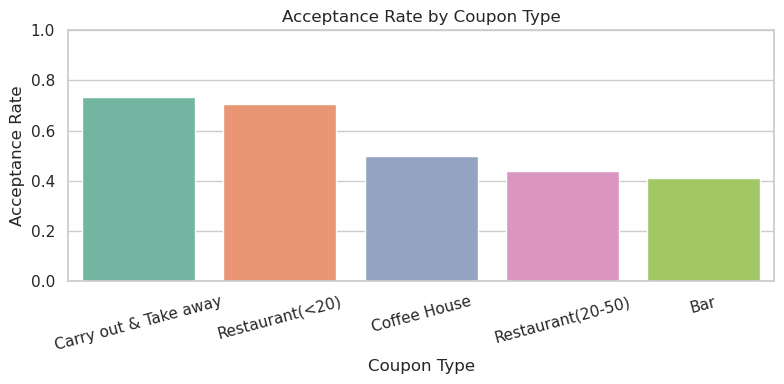

In [32]:

# Cell 14 — Acceptance rate by coupon type (highlight 'Bar')

# Compute order by acceptance rate (highest to lowest)
accept_by_coupon = df.groupby("coupon")["Y"].mean().sort_values(ascending=False)
order = accept_by_coupon.index

# Build a distinct color for each coupon type (aligned to `order`)
colors = sns.color_palette("Set2", n_colors=len(order))  # or "tab10", "Paired", etc.
palette = dict(zip(order, colors))  # map category -> color

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=df,
    x="coupon",
    y="Y",
    order=order,
    hue="coupon",          # <- required when passing a palette (Seaborn ≥0.13)
    palette=palette,       # each category gets a distinct color
    dodge=False,           # one bar per category
    legend=False,          # hide redundant legend (hue == x)
    errorbar=None          # optional: suppress CI/error bars
)

ax.set_title("Acceptance Rate by Coupon Type")
ax.set_xlabel("Coupon Type")
ax.set_ylabel("Acceptance Rate")
ax.set_ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


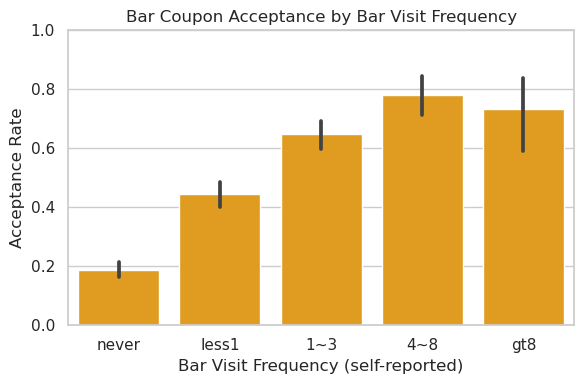

In [33]:
# Cell 15 Bar coupon acceptance by self-reported bar frequency
plt.figure(figsize=(6,4))
order = ["never", "less1", "1~3", "4~8", "gt8"]
order = [c for c in order if c in bar_df["Bar"].dropna().unique()]
sns.barplot(data=bar_df, x="Bar", y="Y", order=order, color="orange", )
plt.title("Bar Coupon Acceptance by Bar Visit Frequency")
plt.xlabel("Bar Visit Frequency (self-reported)")
plt.ylabel("Acceptance Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Coffee House rows: 3996
Coffee House acceptance rate: 0.499


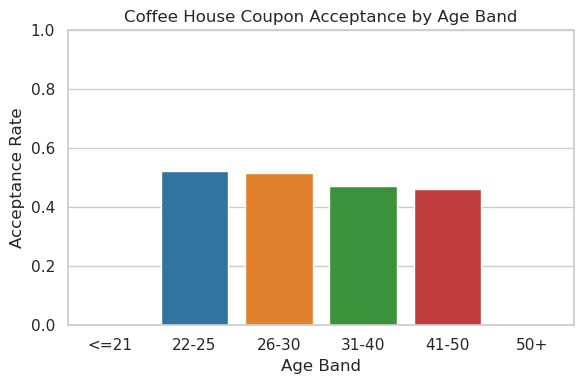

In [35]:
# Cell 16 — Explore Coffee House coupons


coffee_df = df.loc[df["coupon"] == "Coffee House"].copy()
print(f"Coffee House rows: {coffee_df.shape[0]}")
print(f"Coffee House acceptance rate: {coffee_df['Y'].mean():.3f}")

# ---- Age parsing helper ----
def parse_age(age_str):
    if pd.isna(age_str):
            return np.nan
    s = str(age_str).strip().lower()
    if "plus" in s:                     # e.g., "50plus" -> 50.0
        return float(s.replace("plus", "").strip())
    try:
        return float(s)
    except ValueError:
        return np.nan

coffee_df["age_num"] = coffee_df["age"].apply(parse_age)

# ---- Age bands (make categorical with a known order) ----
bins = [0, 21, 26, 31, 41, 51, 200]
labels = ["<=21", "22-25", "26-30", "31-40", "41-50", "50+"]
coffee_df["age_band"] = pd.cut(
    coffee_df["age_num"], bins=bins, labels=labels, right=False
)

# ---- Acceptance by age band (set observed to silence FutureWarning) ----
acc_by_age = coffee_df.groupby("age_band", observed=True)["Y"].mean()

# Build a tidy frame and keep only bands that actually appear (drop all-NaN groups)
acc_df = acc_by_age.dropna().reset_index(name="accept_rate")

# Ensure age_band stays a categorical in the intended order
acc_df["age_band"] = pd.Categorical(acc_df["age_band"], categories=labels, ordered=True)

# ---- Build a palette mapped EXACTLY to the categorical levels in order ----
present_levels = [lvl for lvl in labels if lvl in acc_df["age_band"].unique()]
colors = sns.color_palette("tab10", n_colors=len(present_levels))
palette = dict(zip(present_levels, colors))

# ---- Plot with hue=age_band (no deprecation), one bar per category, multi-color ----
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=acc_df,
    x="age_band",
    y="accept_rate",
    hue="age_band",          # required when passing a palette in seaborn>=0.13
    hue_order=present_levels,
    palette=palette,         # different color per band
    dodge=False,             # single bar per category
    errorbar=None            # optional: hide CI bars
)

# Remove the legend instead of using legend=False parameter
ax.get_legend().remove()  # This is the correct way to hide the legend

ax.set_title("Coffee House Coupon Acceptance by Age Band")
ax.set_xlabel("Age Band")
ax.set_ylabel("Acceptance Rate")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()